# 1. Introduction and Role of Full Retraining

This notebook rebuilds the Adult Income full-retraining reference experiment. Notebook 1 represents the original model before deletion. This notebook defines five forget/retain scenarios and trains fresh MLPs using only the corresponding retain records.

The experiment is a **model-level full-retraining reference**: the neural network is retrained without the forget records, while the fixed preprocessing fitted in Notebook 1 is reused. This keeps full retraining comparable with later approximate unlearning methods, but it is not a complete end-to-end deletion procedure because data-dependent preprocessing is not refitted.

For direct MIA, the verified training history is known:

- Original baseline models trained on every original training record, so every later forget record is a genuine baseline member.
- Full-retraining models train only on retain records, so the corresponding forget records are genuine non-members for that retrained model.

The MIA hypothesis is that forget records may look more member-like under the original baseline than under full retraining. This is tested transparently using per-record loss and true-class confidence only. It is a hypothesis, not a guaranteed result.


# 2. Imports and Reproducibility Configuration

The notebook uses Notebook 1's saved configuration and the same three training seeds. Separate constants are used for model-training seeds, forget-set selection seeds and synthetic date generation.


In [1]:
from pathlib import Path
import json
import random
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.stats import wasserstein_distance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_ROOT = Path.cwd().parents[1]
BASELINE_PROCESSED_DIR = PROJECT_ROOT / "data/processed/adult/rebuilt"
BASELINE_MODEL_DIR = PROJECT_ROOT / "models/adult/rebuilt"
BASELINE_RESULTS_DIR = PROJECT_ROOT / "results/baseline/adult/rebuilt"
RESULTS_DIR = PROJECT_ROOT / "results/full_retraining/adult/rebuilt"
FORGET_DIR = RESULTS_DIR / "forget_sets"
RETAIN_DIR = RESULTS_DIR / "retain_sets"
MATCHED_TEST_DIR = RESULTS_DIR / "matched_test_sets"
MODEL_DIR = RESULTS_DIR / "models"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
METRICS_DIR = RESULTS_DIR / "metrics"

for directory in [RESULTS_DIR, FORGET_DIR, RETAIN_DIR, MATCHED_TEST_DIR, MODEL_DIR, FIGURES_DIR, TABLES_DIR, METRICS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_TRAINING_SEEDS = [42, 43, 44]
FORGET_SELECTION_SEEDS = {
    "s1_random_1_percent": 42,
    "s2_random_5_percent": 43,
    "s3_different_random_5_percent": 44,
    "s4_random_10_percent": 45,
}
SYNTHETIC_DATE_SEED = 142
MIA_MATCHING_SEED = 242
MIA_BOOTSTRAP_RESAMPLES = 2000

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


# 3. Load and Validate Notebook 1 Outputs

Only saved rebuilt outputs from Notebook 1 are loaded. The notebook checks that the three baseline checkpoints exist and that processed feature columns match the checkpoint metadata.


In [2]:
X_train_processed = pd.read_csv(BASELINE_PROCESSED_DIR / "X_train_processed.csv", index_col=0)
X_val_processed = pd.read_csv(BASELINE_PROCESSED_DIR / "X_val_processed.csv", index_col=0)
X_test_processed = pd.read_csv(BASELINE_PROCESSED_DIR / "X_test_processed.csv", index_col=0)
X_train_raw = pd.read_csv(BASELINE_PROCESSED_DIR / "X_train_raw.csv", index_col=0)
X_test_raw = pd.read_csv(BASELINE_PROCESSED_DIR / "X_test_raw.csv", index_col=0)
y_train = pd.read_csv(BASELINE_PROCESSED_DIR / "y_train.csv", index_col=0).squeeze("columns").astype(int)
y_val = pd.read_csv(BASELINE_PROCESSED_DIR / "y_val.csv", index_col=0).squeeze("columns").astype(int)
y_test = pd.read_csv(BASELINE_PROCESSED_DIR / "y_test.csv", index_col=0).squeeze("columns").astype(int)

baseline_metrics_by_seed = pd.read_csv(BASELINE_RESULTS_DIR / "metrics/baseline_metrics_by_seed.csv")
baseline_record_outputs = pd.read_csv(BASELINE_RESULTS_DIR / "tables/baseline_record_outputs.csv")
preprocessor = joblib.load(BASELINE_MODEL_DIR / "adult_preprocessor.joblib")

baseline_checkpoints = {}
for seed in MODEL_TRAINING_SEEDS:
    checkpoint_path = BASELINE_MODEL_DIR / f"adult_baseline_seed_{seed}.pt"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing baseline checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    baseline_checkpoints[seed] = checkpoint

reference_checkpoint = baseline_checkpoints[MODEL_TRAINING_SEEDS[0]]
HIDDEN_LAYER_DIMS = tuple(reference_checkpoint["hidden_layer_dims"])
DROPOUT_PROBABILITY = float(reference_checkpoint["dropout_probability"])
BATCH_SIZE = int(reference_checkpoint["batch_size"])
LEARNING_RATE = float(reference_checkpoint["learning_rate"])
MAX_EPOCHS = int(reference_checkpoint["max_epochs"])
EARLY_STOPPING_PATIENCE = int(reference_checkpoint["early_stopping_patience"])
EARLY_STOPPING_MIN_DELTA = float(reference_checkpoint["early_stopping_min_delta"])
CLASSIFICATION_THRESHOLD = float(reference_checkpoint["classification_threshold"])
PROCESSED_FEATURE_NAMES = list(reference_checkpoint["processed_feature_names"])
INPUT_DIM = int(reference_checkpoint["input_dim"])
PREPROCESSING_STRATEGY = "fixed_notebook1_rebuilt_preprocessing"

if list(X_train_processed.columns) != PROCESSED_FEATURE_NAMES:
    raise ValueError("Processed train columns do not match baseline checkpoint feature names.")
if X_train_processed.shape[1] != INPUT_DIM:
    raise ValueError("Processed feature width does not match baseline input dimension.")

training_index = np.array(sorted(X_train_processed.index.to_numpy()), dtype=int)
training_index_set = set(training_index)

print(f"Loaded rebuilt Notebook 1 outputs with input dimension {INPUT_DIM}.")
print(f"Training/validation/test sizes: {len(X_train_processed)}, {len(X_val_processed)}, {len(X_test_processed)}")
display(baseline_metrics_by_seed)


Loaded rebuilt Notebook 1 outputs with input dimension 91.
Training/validation/test sizes: 34189, 7326, 7327


,seed,accuracy,positive_class_precision,positive_class_recall,f1_score,predictive_auroc,test_loss
0,42,0.856012,0.733601,0.625214,0.675085,0.909657,0.312553
1,43,0.857650,0.759883,0.592128,0.665598,0.910031,0.311535
2,44,0.858742,0.752817,0.609812,0.673810,0.910135,0.311865


# 4. Create Independent Synthetic Dates for S5

The S5 retention-expiry scenario uses artificial dates generated uniformly and reproducibly between 1 January 2015 and 31 December 2025. These dates are independent of income, workclass and all model features by construction because they are sampled from a random generator using only row count and a seed.

The dates have no historical meaning and are not used as model inputs.


In [3]:
collection_start_date = pd.Timestamp("2015-01-01")
collection_end_date = pd.Timestamp("2025-12-31")
retention_reference_date = pd.Timestamp("2025-12-31")
retention_years = 9
retention_cutoff_date = retention_reference_date - pd.DateOffset(years=retention_years)

date_rng = np.random.default_rng(SYNTHETIC_DATE_SEED)
date_range_days = (collection_end_date - collection_start_date).days
synthetic_offsets = date_rng.integers(0, date_range_days + 1, size=len(X_train_processed))
synthetic_dates = collection_start_date + pd.to_timedelta(synthetic_offsets, unit="D")

synthetic_date_table = pd.DataFrame({"original_index": training_index, "synthetic_collection_date": synthetic_dates}).set_index("original_index")

print(f"Synthetic date range: {synthetic_date_table['synthetic_collection_date'].min().date()} to {synthetic_date_table['synthetic_collection_date'].max().date()}")
print(f"Retention cutoff: records before {retention_cutoff_date.date()} are forgotten in S5.")
display(synthetic_date_table["synthetic_collection_date"].dt.year.value_counts().sort_index().rename_axis("year").reset_index(name="count"))


Synthetic date range: 2015-01-01 to 2025-12-31
Retention cutoff: records before 2016-12-31 are forgotten in S5.


,year,count
0,2015,3114
1,2016,3097
2,2017,3099
3,2018,3081
4,2019,3200
5,2020,3018
6,2021,3151
7,2022,3041
8,2023,3177
9,2024,3114


# 5. Define the Five Forget/Retain Scenarios

The random scenarios use fixed selection seeds. S5 uses only the independent synthetic dates.


In [4]:
def sample_training_indices(fraction, seed):
    rng = np.random.default_rng(seed)
    sample_size = int(round(len(training_index) * fraction))
    return np.array(sorted(rng.choice(training_index, size=sample_size, replace=False)), dtype=int)

scenario_configs = [
    {"scenario": "s1_random_1_percent", "display_name": "Random 1%", "rule": "Random 1%", "expected_count": 342},
    {"scenario": "s2_random_5_percent", "display_name": "Random 5%", "rule": "Random 5%", "expected_count": 1709},
    {"scenario": "s3_different_random_5_percent", "display_name": "Different random 5%", "rule": "Different random 5%", "expected_count": 1709},
    {"scenario": "s4_random_10_percent", "display_name": "Random 10%", "rule": "Random 10%", "expected_count": 3419},
    {"scenario": "s5_retention_expiry", "display_name": "Date retention expiry", "rule": "Synthetic date before retention cutoff", "expected_count": None},
]

forget_indices = {
    "s1_random_1_percent": sample_training_indices(0.01, FORGET_SELECTION_SEEDS["s1_random_1_percent"]),
    "s2_random_5_percent": sample_training_indices(0.05, FORGET_SELECTION_SEEDS["s2_random_5_percent"]),
    "s3_different_random_5_percent": sample_training_indices(0.05, FORGET_SELECTION_SEEDS["s3_different_random_5_percent"]),
    "s4_random_10_percent": sample_training_indices(0.10, FORGET_SELECTION_SEEDS["s4_random_10_percent"]),
    "s5_retention_expiry": np.array(sorted(synthetic_date_table[synthetic_date_table["synthetic_collection_date"] < retention_cutoff_date].index.to_numpy()), dtype=int),
}
retain_indices = {scenario: np.array(sorted(training_index_set - set(indices)), dtype=int) for scenario, indices in forget_indices.items()}

s2_s3_overlap = len(set(forget_indices["s2_random_5_percent"]) & set(forget_indices["s3_different_random_5_percent"]))
print(f"S2/S3 overlap: {s2_s3_overlap}")
print(f"S5 forget count: {len(forget_indices['s5_retention_expiry'])}")


S2/S3 overlap: 86
S5 forget count: 6204


# 6. Validate Scenario Membership and Coverage

Every forget/retain pair must be disjoint, reconstruct the original training set, and keep forget records out of the retraining indices. The baseline training set contains every forget record by construction.


In [5]:
scenario_rows = []
validation_rows = []
class_distribution_rows = []

for config in scenario_configs:
    scenario = config["scenario"]
    forget = forget_indices[scenario]
    retain = retain_indices[scenario]
    forget_set = set(forget)
    retain_set = set(retain)
    if config["expected_count"] is not None and len(forget) != config["expected_count"]:
        raise ValueError(f"{scenario} forget count {len(forget)} != expected {config['expected_count']}")
    validation = {
        "scenario": scenario,
        "forget_retain_overlap": len(forget_set & retain_set),
        "coverage_count": len(forget_set | retain_set),
        "coverage_matches_training": (forget_set | retain_set) == training_index_set,
        "forget_indices_valid": forget_set.issubset(training_index_set),
        "retain_indices_valid": retain_set.issubset(training_index_set),
        "forget_records_in_baseline_training": forget_set.issubset(training_index_set),
        "forget_records_absent_from_retain": len(forget_set & retain_set) == 0,
    }
    validation["passed"] = (
        validation["forget_retain_overlap"] == 0
        and validation["coverage_matches_training"]
        and validation["forget_indices_valid"]
        and validation["retain_indices_valid"]
        and validation["forget_records_in_baseline_training"]
        and validation["forget_records_absent_from_retain"]
    )
    validation_rows.append(validation)
    scenario_rows.append(
        {
            "display_name": config["display_name"],
            "scenario": scenario,
            "forget_count": len(forget),
            "forget_percentage": len(forget) / len(training_index) * 100,
            "retain_count": len(retain),
            "retain_percentage": len(retain) / len(training_index) * 100,
            "forget_positive_rate": y_train.loc[forget].mean(),
            "retain_positive_rate": y_train.loc[retain].mean(),
            "rule": config["rule"],
        }
    )
    for subset_name, subset_indices in [("forget", forget), ("retain", retain)]:
        counts = y_train.loc[subset_indices].value_counts().sort_index()
        for label, count in counts.items():
            class_distribution_rows.append({"scenario": scenario, "subset": subset_name, "class_label": int(label), "count": int(count), "percentage": count / len(subset_indices) * 100})

scenario_summary = pd.DataFrame(scenario_rows)
scenario_validation = pd.DataFrame(validation_rows)
scenario_class_distribution = pd.DataFrame(class_distribution_rows)

if not scenario_validation["passed"].all():
    display(scenario_validation)
    raise ValueError("Scenario validation failed.")
if np.array_equal(forget_indices["s2_random_5_percent"], forget_indices["s3_different_random_5_percent"]):
    raise ValueError("S2 and S3 must not be identical.")

display(scenario_summary)
display(scenario_validation)
display(scenario_class_distribution)


,display_name,scenario,forget_count,forget_percentage,retain_count,retain_percentage,forget_positive_rate,retain_positive_rate,rule
0,Random 1%,s1_random_1_percent,342,1.000322,33847,98.999678,0.222222,0.239460,Random 1%
1,Random 5%,s2_random_5_percent,1709,4.998684,32480,95.001316,0.234055,0.239563,Random 5%
2,Different random 5%,s3_different_random_5_percent,1709,4.998684,32480,95.001316,0.245758,0.238947,Different random 5%
3,Random 10%,s4_random_10_percent,3419,10.000292,30770,89.999708,0.234279,0.239844,Random 10%
4,Date retention expiry,s5_retention_expiry,6204,18.146187,27985,81.853813,0.249033,0.237127,Synthetic date before retention cutoff


,scenario,forget_retain_overlap,coverage_count,coverage_matches_training,forget_indices_valid,retain_indices_valid,forget_records_in_baseline_training,forget_records_absent_from_retain,passed
0,s1_random_1_percent,0,34189,True,True,True,True,True,True
1,s2_random_5_percent,0,34189,True,True,True,True,True,True
2,s3_different_random_5_percent,0,34189,True,True,True,True,True,True
3,s4_random_10_percent,0,34189,True,True,True,True,True,True
4,s5_retention_expiry,0,34189,True,True,True,True,True,True


,scenario,subset,class_label,count,percentage
0,s1_random_1_percent,forget,0,266,77.777778
1,s1_random_1_percent,forget,1,76,22.222222
2,s1_random_1_percent,retain,0,25742,76.054008
3,s1_random_1_percent,retain,1,8105,23.945992
4,s2_random_5_percent,forget,0,1309,76.594500
5,s2_random_5_percent,forget,1,400,23.405500
6,s2_random_5_percent,retain,0,24699,76.043719
7,s2_random_5_percent,retain,1,7781,23.956281
8,s3_different_random_5_percent,forget,0,1289,75.424225
9,s3_different_random_5_percent,forget,1,420,24.575775


# 7. Define Full-Retraining Procedure

For each scenario and seed, a fresh MLP is trained from random initialisation using only retain records. The unchanged validation set is used for early stopping, and the unchanged test set is used only for final evaluation.


In [6]:
class AdultIncomeMLP(nn.Module):
    def __init__(self, input_dim, hidden_layer_dims=HIDDEN_LAYER_DIMS, dropout_probability=DROPOUT_PROBABILITY):
        super().__init__()
        hidden_1, hidden_2 = hidden_layer_dims
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout_probability),
            nn.Linear(hidden_2, 1),
        )
    def forward(self, features):
        return self.network(features)


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_dataset(features, labels):
    return TensorDataset(torch.tensor(features.values, dtype=torch.float32), torch.tensor(labels.values, dtype=torch.float32).view(-1, 1))


def make_loader(dataset, shuffle=False, seed=None):
    generator = None
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(seed)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, generator=generator)


def average_loss(model, loader, criterion):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            total += criterion(model(features), labels).item() * features.size(0)
    return total / len(loader.dataset)


def train_retrained_model(scenario, seed):
    set_all_seeds(seed)
    model = AdultIncomeMLP(INPUT_DIM).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    retain_idx = retain_indices[scenario]
    train_loader = make_loader(make_dataset(X_train_processed.loc[retain_idx], y_train.loc[retain_idx]), shuffle=True, seed=seed)
    val_loader = make_loader(make_dataset(X_val_processed, y_val), shuffle=False)
    best_loss = float("inf")
    best_epoch = 0
    best_state = None
    patience_count = 0
    history_rows = []
    start = time.perf_counter()
    early_stopping_triggered = False
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss_sum = 0.0
        for features, labels in train_loader:
            features = features.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss_sum += loss.item() * features.size(0)
        train_loss = train_loss_sum / len(train_loader.dataset)
        val_loss = average_loss(model, val_loader, criterion)
        history_rows.append({"scenario": scenario, "seed": seed, "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        if val_loss < best_loss - EARLY_STOPPING_MIN_DELTA:
            best_loss = val_loss
            best_epoch = epoch
            patience_count = 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        else:
            patience_count += 1
        if patience_count >= EARLY_STOPPING_PATIENCE:
            early_stopping_triggered = True
            break
    runtime = time.perf_counter() - start
    model.load_state_dict({key: value.to(device) for key, value in best_state.items()})
    summary = {"scenario": scenario, "seed": seed, "best_epoch": best_epoch, "best_val_loss": best_loss, "epochs_run": len(history_rows), "runtime_seconds": runtime, "early_stopping_triggered": early_stopping_triggered}
    return model, pd.DataFrame(history_rows), summary


def predict_records(model, features, labels, model_type, scenario, seed, subset):
    loader = make_loader(make_dataset(features, labels), shuffle=False)
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    rows = []
    model.eval()
    pos = 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_size = batch_features.size(0)
            batch_features = batch_features.to(device)
            batch_labels_device = batch_labels.to(device)
            logits = model(batch_features)
            probabilities = torch.sigmoid(logits).cpu().numpy().ravel()
            losses = criterion(logits, batch_labels_device).cpu().numpy().ravel()
            true_values = batch_labels.numpy().ravel().astype(int)
            indices = features.index[pos:pos + batch_size]
            for original_index, true_label, probability, loss in zip(indices, true_values, probabilities, losses):
                y_pred = int(probability >= CLASSIFICATION_THRESHOLD)
                rows.append({"original_index": int(original_index), "model_type": model_type, "scenario": scenario, "seed": seed, "subset": subset, "y_true": int(true_label), "y_pred": y_pred, "y_probability": float(probability), "per_record_loss": float(loss), "negative_loss": float(-loss), "true_class_confidence": float(probability if true_label == 1 else 1 - probability), "correct_prediction": int(y_pred == true_label)})
            pos += batch_size
    return pd.DataFrame(rows)


def load_baseline_model(seed):
    checkpoint = baseline_checkpoints[seed]
    model = AdultIncomeMLP(INPUT_DIM).to(device)
    model.load_state_dict({key: value.to(device) for key, value in checkpoint["model_state_dict"].items()})
    model.eval()
    return model


# 8. Train Full-Retraining References Across Three Seeds

This trains 15 fresh full-retraining references: five scenarios times three seeds. No model is initialised from baseline weights.


In [7]:
retrained_models = {}
training_histories = []
runtime_rows = []
retrained_record_outputs = []

for config in scenario_configs:
    scenario = config["scenario"]
    for seed in MODEL_TRAINING_SEEDS:
        model, history, summary = train_retrained_model(scenario, seed)
        retrained_models[(scenario, seed)] = model
        training_histories.append(history)
        runtime_rows.append(summary)
        print(f"{scenario}, seed {seed}: best_epoch={summary['best_epoch']}, epochs={summary['epochs_run']}, runtime={summary['runtime_seconds']:.2f}s")
        retrained_record_outputs.append(predict_records(model, X_test_processed, y_test, "full_retraining", scenario, seed, "test"))

full_retraining_training_histories = pd.concat(training_histories, ignore_index=True)
runtime_by_seed = pd.DataFrame(runtime_rows)
full_retraining_test_outputs = pd.concat(retrained_record_outputs, ignore_index=True)
display(runtime_by_seed)


s1_random_1_percent, seed 42: best_epoch=9, epochs=12, runtime=7.38s


s1_random_1_percent, seed 43: best_epoch=14, epochs=17, runtime=9.77s


s1_random_1_percent, seed 44: best_epoch=13, epochs=16, runtime=9.44s


s2_random_5_percent, seed 42: best_epoch=12, epochs=15, runtime=8.33s


s2_random_5_percent, seed 43: best_epoch=13, epochs=16, runtime=8.80s


...

s4_random_10_percent, seed 44: best_epoch=10, epochs=13, runtime=6.86s


s5_retention_expiry, seed 42: best_epoch=8, epochs=11, runtime=5.61s


s5_retention_expiry, seed 43: best_epoch=11, epochs=14, runtime=6.77s


s5_retention_expiry, seed 44: best_epoch=15, epochs=18, runtime=8.65s


,scenario,seed,best_epoch,best_val_loss,epochs_run,runtime_seconds,early_stopping_triggered
0,s1_random_1_percent,42,9,0.300915,12,7.375108,True
1,s1_random_1_percent,43,14,0.300444,17,9.765724,True
2,s1_random_1_percent,44,13,0.301016,16,9.440745,True
3,s2_random_5_percent,42,12,0.301174,15,8.326534,True
4,s2_random_5_percent,43,13,0.300641,16,8.797483,True
5,s2_random_5_percent,44,13,0.300841,16,8.744736,True
6,s3_different_random_5_percent,42,6,0.302205,9,5.007896,True
7,s3_different_random_5_percent,43,9,0.301390,12,6.643698,True
8,s3_different_random_5_percent,44,9,0.301434,12,6.552407,True
9,s4_random_10_percent,42,10,0.301386,13,6.905017,True


# 9. Main Results Summary

The first results table is intentionally concise: scenario size, predictive utility mean ± standard deviation, and runtime mean ± standard deviation across the three seeds.


In [8]:
utility_rows = []
classification_rows = []
confusion_rows = []
roc_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    for seed in MODEL_TRAINING_SEEDS:
        records = full_retraining_test_outputs[(full_retraining_test_outputs["scenario"] == scenario) & (full_retraining_test_outputs["seed"] == seed)]
        y_true = records["y_true"].to_numpy()
        y_pred = records["y_pred"].to_numpy()
        y_prob = records["y_probability"].to_numpy()
        utility_rows.append({"display_name": config["display_name"], "scenario": scenario, "seed": seed, "accuracy": accuracy_score(y_true, y_pred), "positive_class_precision": precision_score(y_true, y_pred, zero_division=0), "positive_class_recall": recall_score(y_true, y_pred, zero_division=0), "f1_score": f1_score(y_true, y_pred), "predictive_auroc": roc_auc_score(y_true, y_prob), "test_loss": records["per_record_loss"].mean()})
        matrix = confusion_matrix(y_true, y_pred)
        confusion_rows.append({"scenario": scenario, "seed": seed, "true_<=50K_pred_<=50K": int(matrix[0,0]), "true_<=50K_pred_>50K": int(matrix[0,1]), "true_>50K_pred_<=50K": int(matrix[1,0]), "true_>50K_pred_>50K": int(matrix[1,1])})
        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
        for label, values in report.items():
            row = {"scenario": scenario, "seed": seed, "label": label}
            if isinstance(values, dict):
                row.update(values)
            else:
                row["f1-score"] = values
            classification_rows.append(row)
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        for fpr_value, tpr_value, threshold in zip(fpr, tpr, thresholds):
            roc_rows.append({"scenario": scenario, "seed": seed, "false_positive_rate": fpr_value, "true_positive_rate": tpr_value, "threshold": threshold})

utility_metrics_by_seed = pd.DataFrame(utility_rows)
classification_reports = pd.DataFrame(classification_rows)
confusion_matrices = pd.DataFrame(confusion_rows)
roc_curves = pd.DataFrame(roc_rows)

aggregate_rows = []
for scenario, group in utility_metrics_by_seed.groupby("scenario"):
    config = next(item for item in scenario_configs if item["scenario"] == scenario)
    runtime_group = runtime_by_seed[runtime_by_seed["scenario"] == scenario]
    scenario_info = scenario_summary[scenario_summary["scenario"] == scenario].iloc[0]
    aggregate_rows.append({"display_name": config["display_name"], "scenario": scenario, "forget_count": int(scenario_info["forget_count"]), "forget_percentage": float(scenario_info["forget_percentage"]), "test_accuracy_mean": group["accuracy"].mean(), "test_accuracy_std": group["accuracy"].std(ddof=1), "test_f1_mean": group["f1_score"].mean(), "test_f1_std": group["f1_score"].std(ddof=1), "predictive_auroc_mean": group["predictive_auroc"].mean(), "predictive_auroc_std": group["predictive_auroc"].std(ddof=1), "runtime_mean": runtime_group["runtime_seconds"].mean(), "runtime_std": runtime_group["runtime_seconds"].std(ddof=1)})
utility_metrics_aggregate = pd.DataFrame(aggregate_rows)

summary_display = utility_metrics_aggregate.copy()
summary_display["Test accuracy mean ± SD"] = summary_display.apply(lambda row: f"{row['test_accuracy_mean']:.4f} ± {row['test_accuracy_std']:.4f}", axis=1)
summary_display["Test F1 mean ± SD"] = summary_display.apply(lambda row: f"{row['test_f1_mean']:.4f} ± {row['test_f1_std']:.4f}", axis=1)
summary_display["Predictive AUROC mean ± SD"] = summary_display.apply(lambda row: f"{row['predictive_auroc_mean']:.4f} ± {row['predictive_auroc_std']:.4f}", axis=1)
summary_display["Runtime mean ± SD"] = summary_display.apply(lambda row: f"{row['runtime_mean']:.2f} ± {row['runtime_std']:.2f}s", axis=1)
display(summary_display[["display_name", "forget_count", "forget_percentage", "Test accuracy mean ± SD", "Test F1 mean ± SD", "Predictive AUROC mean ± SD", "Runtime mean ± SD"]])


,display_name,forget_count,forget_percentage,Test accuracy mean ± SD,Test F1 mean ± SD,Predictive AUROC mean ± SD,Runtime mean ± SD
0,Random 1%,342,1.000322,0.8589 ± 0.0010,0.6780 ± 0.0040,0.9097 ± 0.0002,8.86 ± 1.30s
1,Random 5%,1709,4.998684,0.8577 ± 0.0012,0.6748 ± 0.0019,0.9094 ± 0.0001,8.62 ± 0.26s
2,Different random 5%,1709,4.998684,0.8584 ± 0.0004,0.6719 ± 0.0056,0.9101 ± 0.0003,6.07 ± 0.92s
3,Random 10%,3419,10.000292,0.8572 ± 0.0015,0.6762 ± 0.0021,0.9093 ± 0.0001,7.39 ± 0.87s
4,Date retention expiry,6204,18.146187,0.8580 ± 0.0006,0.6781 ± 0.0017,0.9098 ± 0.0001,7.01 ± 1.54s


# 10. Detailed Predictive Utility Results

Per-seed results are compared with the matching baseline seed. These are descriptive model-level comparisons, not significance tests.


In [9]:
baseline_metric_lookup = baseline_metrics_by_seed.set_index("seed")
for metric in ["accuracy", "f1_score", "predictive_auroc"]:
    utility_metrics_by_seed[f"{metric}_difference_from_baseline"] = utility_metrics_by_seed.apply(lambda row: row[metric] - baseline_metric_lookup.loc[row["seed"], metric], axis=1)

difference_summary = utility_metrics_by_seed.groupby(["display_name", "scenario"])[["accuracy_difference_from_baseline", "f1_score_difference_from_baseline", "predictive_auroc_difference_from_baseline"]].agg(["mean", "std"]).reset_index()
display(utility_metrics_by_seed)
display(difference_summary)


,display_name,scenario,seed,accuracy,positive_class_precision,positive_class_recall,f1_score,predictive_auroc,test_loss,accuracy_difference_from_baseline,f1_score_difference_from_baseline,predictive_auroc_difference_from_baseline
0,Random 1%,s1_random_1_percent,42,0.857786,0.742001,0.621791,0.676598,0.909855,0.312082,0.001774,0.001514,0.000199
1,Random 1%,s1_random_1_percent,43,0.859561,0.743280,0.630918,0.682505,0.909423,0.312689,0.001911,0.016907,-0.000607
2,Random 1%,s1_random_1_percent,44,0.859424,0.755477,0.609812,0.674874,0.909740,0.312696,0.000682,0.001063,-0.000395
3,Random 5%,s2_random_5_percent,42,0.856421,0.734762,0.625784,0.675909,0.909359,0.312990,0.000409,0.000824,-0.000297
4,Random 5%,s2_random_5_percent,43,0.857923,0.749649,0.609812,0.672539,0.909541,0.312369,0.000273,0.006941,-0.000490
5,Random 5%,s2_random_5_percent,44,0.858878,0.750174,0.614946,0.675862,0.909350,0.312603,0.000136,0.002052,-0.000786
6,Different random 5%,s3_different_random_5_percent,42,0.857923,0.746196,0.615516,0.674586,0.910019,0.311526,0.001911,-0.000499,0.000362
7,Different random 5%,s3_different_random_5_percent,43,0.858742,0.767910,0.586994,0.665373,0.910441,0.310597,0.001092,-0.000225,0.000410
8,Different random 5%,s3_different_random_5_percent,44,0.858605,0.748786,0.615516,0.675642,0.909880,0.312094,-0.000136,0.001832,-0.000255
9,Random 10%,s4_random_10_percent,42,0.855466,0.732262,0.624073,0.673853,0.909438,0.312756,-0.000546,-0.001232,-0.000219


display_name                       scenario  \
                                                          
0  Date retention expiry            s5_retention_expiry   
1    Different random 5%  s3_different_random_5_percent   
2              Random 1%            s1_random_1_percent   
3             Random 10%           s4_random_10_percent   
4              Random 5%            s2_random_5_percent   

  accuracy_difference_from_baseline            \
                               mean       std   
0                          0.000546  0.001444   
1                          0.000955  0.001030   
2                          0.001456  0.000673   
3                         -0.000273  0.000473   
4                          0.000273  0.000136   

  f1_score_difference_from_baseline            \
                               mean       std   
0                          0.006583  0.006846   
1                          0.000369  0.001274   
2                          0.006495  0.009020   
3                          0.004733  0.006352   
4                          0.003272  0.003236   

  predictive_auroc_difference_from_baseline            
                                       mean       std  
0                                 -0.000172  0.000136  
1                                  0.000172  0.000371  
2                                 -0.000268  0.000418  
3                                 -0.000619  0.000351  
4                                 -0.000524  0.000246

# 11. Forget and Retain Behaviour

Full retraining does not require forget accuracy to collapse. A model trained without particular records may still predict them correctly by learning general patterns from retained records.


,display_name,scenario,seed,model_type,subset,accuracy,mean_loss,mean_true_class_confidence,mean_predicted_probability,positive_prediction_rate
0,Random 1%,s1_random_1_percent,42,baseline,forget,0.847953,0.304658,0.806523,0.234838,0.216374
1,Random 1%,s1_random_1_percent,42,baseline,retain,0.859988,0.298870,0.805352,0.245838,0.210536
2,Random 1%,s1_random_1_percent,42,baseline,test,0.856012,0.312553,0.800279,0.243792,0.203903
3,Random 1%,s1_random_1_percent,42,full_retraining,forget,0.847953,0.314262,0.805059,0.229792,0.210526
4,Random 1%,s1_random_1_percent,42,full_retraining,retain,0.860047,0.299450,0.806945,0.241908,0.205336
5,Random 1%,s1_random_1_percent,42,full_retraining,test,0.857786,0.312082,0.802211,0.239813,0.200491
6,Random 1%,s1_random_1_percent,43,baseline,forget,0.850877,0.307960,0.807252,0.220499,0.195906
7,Random 1%,s1_random_1_percent,43,baseline,retain,0.859781,0.299790,0.806206,0.233000,0.190298
8,Random 1%,s1_random_1_percent,43,baseline,test,0.857650,0.311535,0.801573,0.231360,0.186434
9,Random 1%,s1_random_1_percent,43,full_retraining,forget,0.853801,0.312807,0.804857,0.232344,0.210526


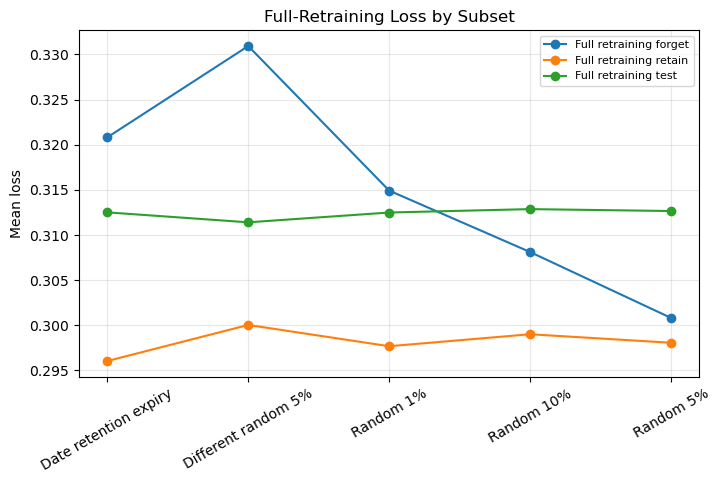

In [10]:
def subset_metrics(records):
    return {"accuracy": accuracy_score(records["y_true"], records["y_pred"]), "mean_loss": records["per_record_loss"].mean(), "mean_true_class_confidence": records["true_class_confidence"].mean(), "mean_predicted_probability": records["y_probability"].mean(), "positive_prediction_rate": records["y_pred"].mean()}

subset_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    for seed in MODEL_TRAINING_SEEDS:
        baseline_model = load_baseline_model(seed)
        retrained_model = retrained_models[(scenario, seed)]
        for model_type, model in [("baseline", baseline_model), ("full_retraining", retrained_model)]:
            for subset_name, indices, features, labels in [
                ("forget", forget_indices[scenario], X_train_processed.loc[forget_indices[scenario]], y_train.loc[forget_indices[scenario]]),
                ("retain", retain_indices[scenario], X_train_processed.loc[retain_indices[scenario]], y_train.loc[retain_indices[scenario]]),
                ("test", X_test_processed.index.to_numpy(), X_test_processed, y_test),
            ]:
                records = predict_records(model, features, labels, model_type, scenario, seed, subset_name)
                row = {"display_name": config["display_name"], "scenario": scenario, "seed": seed, "model_type": model_type, "subset": subset_name}
                row.update(subset_metrics(records))
                subset_rows.append(row)
subset_behaviour_by_seed = pd.DataFrame(subset_rows)
display(subset_behaviour_by_seed.head(15))

subset_fig, subset_ax = plt.subplots(figsize=(8, 4.5))
plot_data = subset_behaviour_by_seed.groupby(["display_name", "model_type", "subset"])["mean_loss"].mean().reset_index()
for subset in ["forget", "retain", "test"]:
    subset_data = plot_data[(plot_data["subset"] == subset) & (plot_data["model_type"] == "full_retraining")]
    subset_ax.plot(subset_data["display_name"], subset_data["mean_loss"], marker="o", label=f"Full retraining {subset}")
subset_ax.set_ylabel("Mean loss")
subset_ax.set_title("Full-Retraining Loss by Subset")
subset_ax.tick_params(axis="x", rotation=30)
subset_ax.legend(fontsize=8)
subset_ax.grid(True, alpha=0.3)
plt.show()


# 12. Baseline versus Full-Retraining Behaviour

For the exact same records and matching seeds, this section measures how much full retraining changed probabilities, predictions, losses and true-class confidence. Small retain/test differences suggest utility preservation; forget-record differences show how much removing records changed model behaviour on those records.


,display_name,scenario,seed,subset,mean_absolute_probability_difference,prediction_agreement,mean_loss_difference_full_minus_baseline,mean_true_class_confidence_difference_full_minus_baseline,record_count
0,Random 1%,s1_random_1_percent,42,forget,0.010891,0.988304,0.009604,-0.001464,342
1,Random 1%,s1_random_1_percent,42,retain,0.010657,0.988300,0.000580,0.001593,33847
2,Random 1%,s1_random_1_percent,42,test,0.010810,0.990037,-0.000471,0.001931,7327
3,Random 1%,s1_random_1_percent,43,forget,0.014001,0.985380,0.004847,-0.002395,342
4,Random 1%,s1_random_1_percent,43,retain,0.015527,0.978403,-0.003487,-0.000017,33847
5,Random 1%,s1_random_1_percent,43,test,0.015314,0.980893,0.001155,-0.001571,7327
6,Random 1%,s1_random_1_percent,44,forget,0.012350,0.988304,0.010116,-0.002270,342
7,Random 1%,s1_random_1_percent,44,retain,0.010330,0.987828,-0.000358,0.001949,33847
8,Random 1%,s1_random_1_percent,44,test,0.010838,0.988399,0.000832,0.001827,7327
9,Random 5%,s2_random_5_percent,42,forget,0.013411,0.984201,0.008253,-0.004383,1709


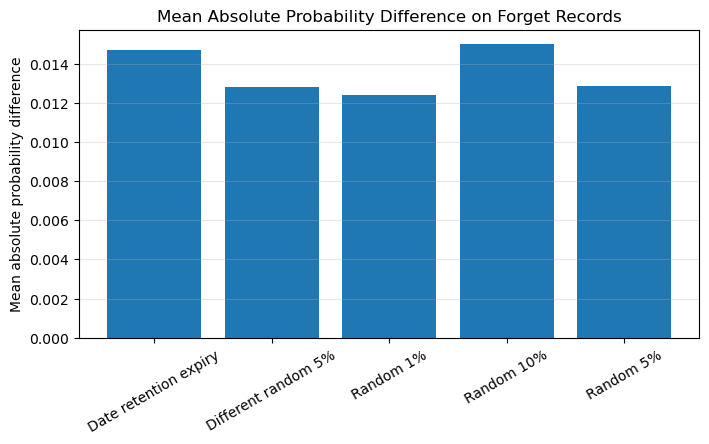

In [11]:
behaviour_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    for seed in MODEL_TRAINING_SEEDS:
        baseline_model = load_baseline_model(seed)
        retrained_model = retrained_models[(scenario, seed)]
        for subset_name, indices, features, labels in [
            ("forget", forget_indices[scenario], X_train_processed.loc[forget_indices[scenario]], y_train.loc[forget_indices[scenario]]),
            ("retain", retain_indices[scenario], X_train_processed.loc[retain_indices[scenario]], y_train.loc[retain_indices[scenario]]),
            ("test", X_test_processed.index.to_numpy(), X_test_processed, y_test),
        ]:
            base_records = predict_records(baseline_model, features, labels, "baseline", scenario, seed, subset_name)
            retrain_records = predict_records(retrained_model, features, labels, "full_retraining", scenario, seed, subset_name)
            merged = base_records.merge(retrain_records, on="original_index", suffixes=("_baseline", "_full_retraining"))
            behaviour_rows.append({"display_name": config["display_name"], "scenario": scenario, "seed": seed, "subset": subset_name, "mean_absolute_probability_difference": (merged["y_probability_baseline"] - merged["y_probability_full_retraining"]).abs().mean(), "prediction_agreement": (merged["y_pred_baseline"] == merged["y_pred_full_retraining"]).mean(), "mean_loss_difference_full_minus_baseline": (merged["per_record_loss_full_retraining"] - merged["per_record_loss_baseline"]).mean(), "mean_true_class_confidence_difference_full_minus_baseline": (merged["true_class_confidence_full_retraining"] - merged["true_class_confidence_baseline"]).mean(), "record_count": len(merged)})
behavioural_similarity_by_seed = pd.DataFrame(behaviour_rows)
display(behavioural_similarity_by_seed)

prob_fig, prob_ax = plt.subplots(figsize=(8, 4))
prob_plot = behavioural_similarity_by_seed[behavioural_similarity_by_seed["subset"] == "forget"].groupby("display_name")["mean_absolute_probability_difference"].mean().reset_index()
prob_ax.bar(prob_plot["display_name"], prob_plot["mean_absolute_probability_difference"])
prob_ax.set_title("Mean Absolute Probability Difference on Forget Records")
prob_ax.set_ylabel("Mean absolute probability difference")
prob_ax.tick_params(axis="x", rotation=30)
prob_ax.grid(True, axis="y", alpha=0.3)
plt.show()


# 13. Direct Membership-Inference Methodology

MIA uses only real baseline and fully retrained MLPs. No shadow models, overfitted controls, neural attacks, logistic-regression attacks or random-forest attacks are used.

Two transparent direct membership scores are evaluated:

- **Negative loss**: lower binary cross-entropy loss gives a higher membership-like score.
- **True-class confidence**: higher probability assigned to the true class is more member-like.

Direct MIA tests detectable membership leakage. It does not establish whether a record was factually used for training; that factual history is already known from the experiment.


In [12]:
def bootstrap_auc(labels, scores, n_bootstrap=MIA_BOOTSTRAP_RESAMPLES, seed=42):
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    rng = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_bootstrap):
        sampled_positions = []
        for label in np.unique(labels):
            positions = np.where(labels == label)[0]
            sampled_positions.extend(rng.choice(positions, size=len(positions), replace=True))
        sampled_positions = np.array(sampled_positions)
        aucs.append(roc_auc_score(labels[sampled_positions], scores[sampled_positions]))
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5)), len(aucs)


def tpr_at_fpr(labels, scores, target_fpr):
    fpr, tpr, _ = roc_curve(labels, scores)
    valid = np.where(fpr <= target_fpr)[0]
    return float(tpr[valid].max()) if len(valid) else 0.0


def attack_metrics(labels, scores, seed):
    ci_low, ci_high, boot_n = bootstrap_auc(labels, scores, seed=seed)
    return {"attack_auroc": roc_auc_score(labels, scores), "attack_auc_ci_low": ci_low, "attack_auc_ci_high": ci_high, "bootstrap_resamples": boot_n, "tpr_at_fpr_0.01": tpr_at_fpr(labels, scores, 0.01), "tpr_at_fpr_0.05": tpr_at_fpr(labels, scores, 0.05), "member_count": int((np.asarray(labels) == 1).sum()), "non_member_count": int((np.asarray(labels) == 0).sum())}


def sample_test_match_by_class(member_indices, seed):
    rng = np.random.default_rng(seed)
    sampled = []
    member_labels = y_train.loc[member_indices]
    for class_label, count in member_labels.value_counts().sort_index().items():
        candidates = y_test[y_test == class_label].index.to_numpy()
        if count > len(candidates):
            raise ValueError(f"Not enough test candidates for class {class_label}.")
        sampled.extend(rng.choice(candidates, size=int(count), replace=False).tolist())
    return np.array(sampled, dtype=int)

matched_test_indices = {}
matched_rows = []
for idx, config in enumerate(scenario_configs):
    scenario = config["scenario"]
    matched = sample_test_match_by_class(forget_indices[scenario], seed=MIA_MATCHING_SEED + idx)
    matched_test_indices[scenario] = matched
    matched_rows.append({"scenario": scenario, "display_name": config["display_name"], "matched_test_count": len(matched), "forget_count": len(forget_indices[scenario]), "matching_seed": MIA_MATCHING_SEED + idx})
matched_test_summary = pd.DataFrame(matched_rows)
display(matched_test_summary)


,scenario,display_name,matched_test_count,forget_count,matching_seed
0,s1_random_1_percent,Random 1%,342,342,242
1,s2_random_5_percent,Random 5%,1709,1709,243
2,s3_different_random_5_percent,Different random 5%,1709,1709,244
3,s4_random_10_percent,Random 10%,3419,3419,245
4,s5_retention_expiry,Date retention expiry,6204,6204,246


# 14. Direct MIA Results

Three direct MIA tests are reported:

- **Test A:** baseline forget records versus matched test non-members.
- **Test B:** full-retraining forget records versus matched test records, where both groups are non-members for the retrained model.
- **Test C:** paired same-record score changes from baseline to full retraining.

Results are displayed per seed and aggregated across the three model seeds.


In [13]:
direct_scores = ["negative_loss", "true_class_confidence"]
baseline_mia_rows = []
retrained_similarity_rows = []
paired_change_rows = []
record_score_rows = []

for config in scenario_configs:
    scenario = config["scenario"]
    display_name = config["display_name"]
    forget_idx = forget_indices[scenario]
    matched_idx = matched_test_indices[scenario]
    for seed in MODEL_TRAINING_SEEDS:
        baseline_model = load_baseline_model(seed)
        retrained_model = retrained_models[(scenario, seed)]
        base_forget = predict_records(baseline_model, X_train_processed.loc[forget_idx], y_train.loc[forget_idx], "baseline", scenario, seed, "forget_member")
        base_test = predict_records(baseline_model, X_test_processed.loc[matched_idx], y_test.loc[matched_idx], "baseline", scenario, seed, "matched_test_nonmember")
        full_forget = predict_records(retrained_model, X_train_processed.loc[forget_idx], y_train.loc[forget_idx], "full_retraining", scenario, seed, "forget_nonmember")
        full_test = predict_records(retrained_model, X_test_processed.loc[matched_idx], y_test.loc[matched_idx], "full_retraining", scenario, seed, "matched_test_nonmember")
        record_score_rows.extend([base_forget, base_test, full_forget, full_test])

        for score_name in direct_scores:
            labels = np.concatenate([np.ones(len(base_forget)), np.zeros(len(base_test))])
            scores = pd.concat([base_forget[score_name], base_test[score_name]]).to_numpy()
            row = {"display_name": display_name, "scenario": scenario, "seed": seed, "attack_score": score_name, "test": "baseline_forget_vs_matched_test"}
            row.update(attack_metrics(labels, scores, seed=seed + 100))
            baseline_mia_rows.append(row)

            group_labels = np.concatenate([np.ones(len(full_forget)), np.zeros(len(full_test))])
            group_scores = pd.concat([full_forget[score_name], full_test[score_name]]).to_numpy()
            sim_row = {"display_name": display_name, "scenario": scenario, "seed": seed, "attack_score": score_name, "test": "full_retraining_forget_vs_matched_test_group_distinguishability"}
            sim_row.update(attack_metrics(group_labels, group_scores, seed=seed + 200))
            sim_row["wasserstein_distance"] = wasserstein_distance(full_forget[score_name], full_test[score_name])
            sim_row["mean_loss_difference_forget_minus_test"] = full_forget["per_record_loss"].mean() - full_test["per_record_loss"].mean()
            sim_row["mean_true_class_confidence_difference_forget_minus_test"] = full_forget["true_class_confidence"].mean() - full_test["true_class_confidence"].mean()
            retrained_similarity_rows.append(sim_row)

            paired = base_forget[["original_index", score_name]].merge(full_forget[["original_index", score_name]], on="original_index", suffixes=("_baseline", "_full_retraining"))
            changes = paired[f"{score_name}_full_retraining"] - paired[f"{score_name}_baseline"]
            rng = np.random.default_rng(seed + 300)
            boot_means = []
            for _ in range(MIA_BOOTSTRAP_RESAMPLES):
                sampled = rng.choice(changes.to_numpy(), size=len(changes), replace=True)
                boot_means.append(sampled.mean())
            paired_change_rows.append({"display_name": display_name, "scenario": scenario, "seed": seed, "attack_score": score_name, "baseline_mean": paired[f"{score_name}_baseline"].mean(), "full_retraining_mean": paired[f"{score_name}_full_retraining"].mean(), "mean_paired_change": changes.mean(), "median_paired_change": changes.median(), "paired_change_ci_low": float(np.percentile(boot_means, 2.5)), "paired_change_ci_high": float(np.percentile(boot_means, 97.5)), "percentage_decreased": (changes < 0).mean() * 100, "standardised_effect_size": changes.mean() / changes.std(ddof=1) if changes.std(ddof=1) > 0 else np.nan, "record_count": len(changes)})

direct_mia_record_scores = pd.concat(record_score_rows, ignore_index=True)
direct_mia_baseline_by_seed = pd.DataFrame(baseline_mia_rows)
direct_mia_retrained_similarity_by_seed = pd.DataFrame(retrained_similarity_rows)
direct_mia_paired_changes_by_seed = pd.DataFrame(paired_change_rows)

aggregate_mia_rows = []
for table_name, table in [("baseline", direct_mia_baseline_by_seed), ("retrained_similarity", direct_mia_retrained_similarity_by_seed), ("paired_changes", direct_mia_paired_changes_by_seed)]:
    value_cols = [column for column in table.columns if column not in ["display_name", "scenario", "seed", "attack_score", "test"] and pd.api.types.is_numeric_dtype(table[column])]
    for (display_name, scenario, attack_score), group in table.groupby(["display_name", "scenario", "attack_score"]):
        row = {"table": table_name, "display_name": display_name, "scenario": scenario, "attack_score": attack_score}
        for col in value_cols:
            row[f"{col}_mean"] = group[col].mean()
            row[f"{col}_std"] = group[col].std(ddof=1)
        aggregate_mia_rows.append(row)
direct_mia_aggregate = pd.DataFrame(aggregate_mia_rows)

baseline_mia_display = direct_mia_baseline_by_seed[direct_mia_baseline_by_seed["attack_score"] == "negative_loss"].copy()
display(baseline_mia_display[["display_name", "seed", "attack_score", "attack_auroc", "attack_auc_ci_low", "attack_auc_ci_high", "tpr_at_fpr_0.01", "tpr_at_fpr_0.05"]])

retrained_similarity_display = direct_mia_retrained_similarity_by_seed[direct_mia_retrained_similarity_by_seed["attack_score"] == "negative_loss"].copy()
display(retrained_similarity_display[["display_name", "seed", "attack_score", "attack_auroc", "attack_auc_ci_low", "attack_auc_ci_high", "wasserstein_distance", "mean_loss_difference_forget_minus_test"]])

paired_display = direct_mia_paired_changes_by_seed[direct_mia_paired_changes_by_seed["attack_score"] == "negative_loss"].copy()
display(paired_display[["display_name", "seed", "attack_score", "baseline_mean", "full_retraining_mean", "mean_paired_change", "paired_change_ci_low", "paired_change_ci_high", "percentage_decreased"]])


,display_name,seed,attack_score,attack_auroc,attack_auc_ci_low,attack_auc_ci_high,tpr_at_fpr_0.01,tpr_at_fpr_0.05
0,Random 1%,42,negative_loss,0.519036,0.474291,0.560824,0.005848,0.052632
2,Random 1%,43,negative_loss,0.517702,0.475574,0.560746,0.008772,0.055556
4,Random 1%,44,negative_loss,0.518506,0.475137,0.562192,0.005848,0.055556
6,Random 5%,42,negative_loss,0.493217,0.475021,0.512626,0.009947,0.047396
8,Random 5%,43,negative_loss,0.493162,0.474986,0.512532,0.011703,0.047981
10,Random 5%,44,negative_loss,0.493982,0.474250,0.512608,0.010532,0.047981
12,Different random 5%,42,negative_loss,0.489636,0.471231,0.508910,0.009947,0.050907
14,Different random 5%,43,negative_loss,0.489599,0.471071,0.508591,0.008777,0.048566
16,Different random 5%,44,negative_loss,0.490603,0.471169,0.510008,0.009362,0.049152
18,Random 10%,42,negative_loss,0.502303,0.488385,0.516261,0.004680,0.045335


,display_name,seed,attack_score,attack_auroc,attack_auc_ci_low,attack_auc_ci_high,wasserstein_distance,mean_loss_difference_forget_minus_test
0,Random 1%,42,negative_loss,0.517638,0.475523,0.561818,0.025395,0.001524
2,Random 1%,43,negative_loss,0.517877,0.474197,0.560072,0.023752,0.000597
4,Random 1%,44,negative_loss,0.516013,0.472791,0.562573,0.029970,0.003124
6,Random 5%,42,negative_loss,0.491442,0.471636,0.510449,0.022495,-0.001245
8,Random 5%,43,negative_loss,0.491982,0.471622,0.511657,0.022035,-0.000861
10,Random 5%,44,negative_loss,0.491777,0.472262,0.510429,0.022105,-0.002638
12,Different random 5%,42,negative_loss,0.487374,0.467879,0.506846,0.029554,0.025599
14,Different random 5%,43,negative_loss,0.487154,0.467458,0.506287,0.033456,0.030912
16,Different random 5%,44,negative_loss,0.488058,0.468582,0.507470,0.028272,0.025298
18,Random 10%,42,negative_loss,0.500044,0.486542,0.513349,0.009343,-0.003195


,display_name,seed,attack_score,baseline_mean,full_retraining_mean,mean_paired_change,paired_change_ci_low,paired_change_ci_high,percentage_decreased
0,Random 1%,42,negative_loss,-0.304658,-0.314262,-0.009604,-0.016412,-0.003429,47.953216
2,Random 1%,43,negative_loss,-0.307960,-0.312807,-0.004847,-0.011515,0.001526,42.105263
4,Random 1%,44,negative_loss,-0.307565,-0.317682,-0.010116,-0.016542,-0.004194,36.842105
6,Random 5%,42,negative_loss,-0.294543,-0.302795,-0.008253,-0.011326,-0.005297,55.880632
8,Random 5%,43,negative_loss,-0.293342,-0.300142,-0.006799,-0.009264,-0.004405,43.007607
10,Random 5%,44,negative_loss,-0.291017,-0.299527,-0.008510,-0.010983,-0.006055,73.727326
12,Different random 5%,42,negative_loss,-0.319851,-0.330370,-0.010519,-0.014297,-0.007142,70.918666
14,Different random 5%,43,negative_loss,-0.322005,-0.332675,-0.010670,-0.015024,-0.006876,38.502048
16,Different random 5%,44,negative_loss,-0.316136,-0.329731,-0.013595,-0.019788,-0.008695,76.653013
18,Random 10%,42,negative_loss,-0.297302,-0.308096,-0.010795,-0.013518,-0.008063,51.594033


# 15. Runtime and Training Stability

Runtime and early-stopping behaviour are summarised by scenario and seed. Runtime is training-loop runtime for full retraining and excludes scenario creation, evaluation and file saving.


,scenario,runtime_mean,runtime_std,epochs_mean,epochs_std
0,s1_random_1_percent,8.860526,1.296631,15.000000,2.645751
1,s2_random_5_percent,8.622918,0.258027,15.666667,0.577350
2,s3_different_random_5_percent,6.068001,0.919211,11.000000,1.732051
3,s4_random_10_percent,7.385114,0.871151,14.000000,1.732051
4,s5_retention_expiry,7.012972,1.535152,14.333333,3.511885


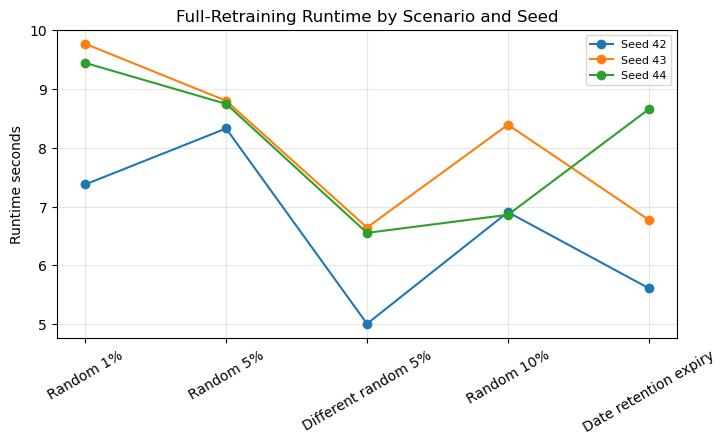

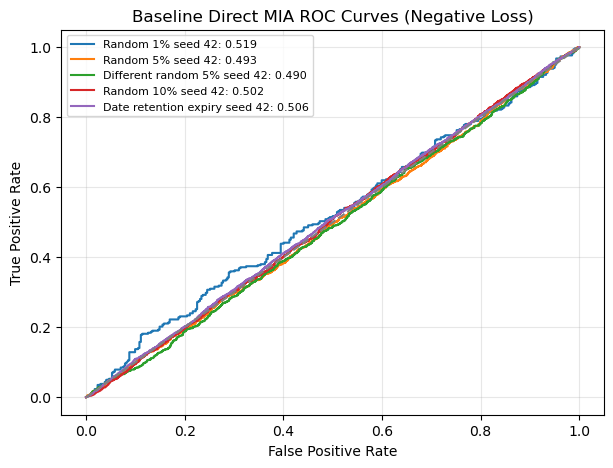

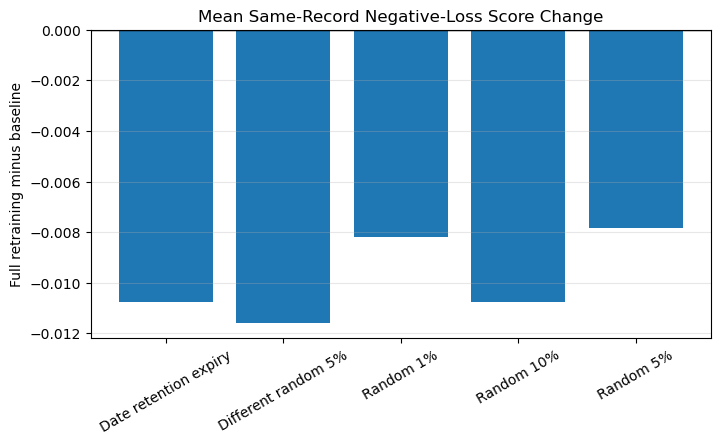

In [14]:
runtime_summary = runtime_by_seed.groupby("scenario").agg(runtime_mean=("runtime_seconds", "mean"), runtime_std=("runtime_seconds", "std"), epochs_mean=("epochs_run", "mean"), epochs_std=("epochs_run", "std")).reset_index()
display(runtime_summary)

runtime_fig, runtime_ax = plt.subplots(figsize=(8, 4))
runtime_plot = runtime_by_seed.merge(scenario_summary[["scenario", "display_name"]], on="scenario")
for seed in MODEL_TRAINING_SEEDS:
    seed_data = runtime_plot[runtime_plot["seed"] == seed]
    runtime_ax.plot(seed_data["display_name"], seed_data["runtime_seconds"], marker="o", label=f"Seed {seed}")
runtime_ax.set_title("Full-Retraining Runtime by Scenario and Seed")
runtime_ax.set_ylabel("Runtime seconds")
runtime_ax.tick_params(axis="x", rotation=30)
runtime_ax.legend(fontsize=8)
runtime_ax.grid(True, alpha=0.3)
plt.show()

mia_roc_fig, mia_roc_ax = plt.subplots(figsize=(7, 5))
for scenario in [config["scenario"] for config in scenario_configs]:
    row_label = scenario_summary.loc[scenario_summary["scenario"] == scenario, "display_name"].iloc[0]
    seed = MODEL_TRAINING_SEEDS[0]
    records = direct_mia_record_scores[(direct_mia_record_scores["scenario"] == scenario) & (direct_mia_record_scores["seed"] == seed) & (direct_mia_record_scores["model_type"] == "baseline")]
    labels = (records["subset"] == "forget_member").astype(int)
    fpr, tpr, _ = roc_curve(labels, records["negative_loss"])
    auc = roc_auc_score(labels, records["negative_loss"])
    mia_roc_ax.plot(fpr, tpr, label=f"{row_label} seed {seed}: {auc:.3f}")
mia_roc_ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
mia_roc_ax.set_title("Baseline Direct MIA ROC Curves (Negative Loss)")
mia_roc_ax.set_xlabel("False Positive Rate")
mia_roc_ax.set_ylabel("True Positive Rate")
mia_roc_ax.legend(fontsize=8)
mia_roc_ax.grid(True, alpha=0.3)
plt.show()

score_fig, score_ax = plt.subplots(figsize=(8, 4))
plot_data = direct_mia_paired_changes_by_seed[direct_mia_paired_changes_by_seed["attack_score"] == "negative_loss"].groupby("display_name")["mean_paired_change"].mean().reset_index()
score_ax.bar(plot_data["display_name"], plot_data["mean_paired_change"])
score_ax.axhline(0, color="black", linewidth=1)
score_ax.set_title("Mean Same-Record Negative-Loss Score Change")
score_ax.set_ylabel("Full retraining minus baseline")
score_ax.tick_params(axis="x", rotation=30)
score_ax.grid(True, axis="y", alpha=0.3)
plt.show()


# 16. Save and Validate Outputs

All rebuilt full-retraining outputs are saved under `results/full_retraining/adult/rebuilt/`. Manifest paths are project-relative.


In [15]:
for config in scenario_configs:
    scenario = config["scenario"]
    np.save(FORGET_DIR / f"{scenario}_forget_indices.npy", forget_indices[scenario])
    np.save(RETAIN_DIR / f"{scenario}_retain_indices.npy", retain_indices[scenario])
    np.save(MATCHED_TEST_DIR / f"{scenario}_matched_test_indices.npy", matched_test_indices[scenario])

for (scenario, seed), model in retrained_models.items():
    checkpoint = {
        "scenario": scenario,
        "seed": seed,
        "model_state_dict": {key: value.detach().cpu().clone() for key, value in model.state_dict().items()},
        "architecture": "AdultIncomeMLP",
        "hidden_layer_dims": HIDDEN_LAYER_DIMS,
        "dropout_probability": DROPOUT_PROBABILITY,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
        "classification_threshold": CLASSIFICATION_THRESHOLD,
        "input_dim": INPUT_DIM,
        "processed_feature_names": PROCESSED_FEATURE_NAMES,
        "preprocessing_strategy": PREPROCESSING_STRATEGY,
        "retain_count": len(retain_indices[scenario]),
        "forget_count": len(forget_indices[scenario]),
    }
    runtime_row = runtime_by_seed[(runtime_by_seed["scenario"] == scenario) & (runtime_by_seed["seed"] == seed)].iloc[0]
    checkpoint.update({"best_epoch": int(runtime_row["best_epoch"]), "best_val_loss": float(runtime_row["best_val_loss"]), "epochs_run": int(runtime_row["epochs_run"]), "runtime_seconds": float(runtime_row["runtime_seconds"]), "early_stopping_triggered": bool(runtime_row["early_stopping_triggered"])})
    torch.save(checkpoint, MODEL_DIR / f"{scenario}_seed_{seed}_full_retrained_mlp.pt")

scenario_summary.to_csv(TABLES_DIR / "scenario_summary.csv", index=False)
scenario_validation.to_csv(TABLES_DIR / "scenario_validation.csv", index=False)
scenario_class_distribution.to_csv(TABLES_DIR / "scenario_class_distribution.csv", index=False)
matched_test_summary.to_csv(TABLES_DIR / "matched_test_summary.csv", index=False)
utility_metrics_by_seed.to_csv(METRICS_DIR / "utility_metrics_by_seed.csv", index=False)
utility_metrics_aggregate.to_csv(METRICS_DIR / "utility_metrics_aggregate.csv", index=False)
classification_reports.to_csv(METRICS_DIR / "classification_reports.csv", index=False)
confusion_matrices.to_csv(METRICS_DIR / "confusion_matrices.csv", index=False)
subset_behaviour_by_seed.to_csv(METRICS_DIR / "subset_behaviour_by_seed.csv", index=False)
behavioural_similarity_by_seed.to_csv(METRICS_DIR / "behavioural_similarity_by_seed.csv", index=False)
direct_mia_baseline_by_seed.to_csv(METRICS_DIR / "direct_mia_baseline_by_seed.csv", index=False)
direct_mia_retrained_similarity_by_seed.to_csv(METRICS_DIR / "direct_mia_retrained_similarity_by_seed.csv", index=False)
direct_mia_paired_changes_by_seed.to_csv(METRICS_DIR / "direct_mia_paired_changes_by_seed.csv", index=False)
direct_mia_aggregate.to_csv(METRICS_DIR / "direct_mia_aggregate.csv", index=False)
direct_mia_record_scores.to_csv(TABLES_DIR / "direct_mia_record_scores.csv", index=False)
full_retraining_training_histories.to_csv(TABLES_DIR / "training_histories.csv", index=False)
runtime_by_seed.to_csv(METRICS_DIR / "runtime_by_seed.csv", index=False)
runtime_summary.to_csv(METRICS_DIR / "runtime_summary.csv", index=False)
full_retraining_test_outputs.to_csv(TABLES_DIR / "test_predictions.csv", index=False)
roc_curves.to_csv(TABLES_DIR / "roc_curves.csv", index=False)
synthetic_date_table.to_csv(TABLES_DIR / "s5_synthetic_dates.csv", index=True)

subset_fig.savefig(FIGURES_DIR / "forget_retain_test_loss_comparison.png", dpi=300, bbox_inches="tight")
prob_fig.savefig(FIGURES_DIR / "forget_probability_difference_from_baseline.png", dpi=300, bbox_inches="tight")
runtime_fig.savefig(FIGURES_DIR / "runtime_by_scenario_seed.png", dpi=300, bbox_inches="tight")
mia_roc_fig.savefig(FIGURES_DIR / "baseline_direct_mia_roc_negative_loss.png", dpi=300, bbox_inches="tight")
score_fig.savefig(FIGURES_DIR / "mia_same_record_score_change.png", dpi=300, bbox_inches="tight")

# Manifest and validation.
def rel(path):
    return str(Path(path).resolve().relative_to(PROJECT_ROOT.resolve()))

manifest_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    manifest_rows.extend([
        {"artifact": f"{scenario}_forget_indices", "path": rel(FORGET_DIR / f"{scenario}_forget_indices.npy")},
        {"artifact": f"{scenario}_retain_indices", "path": rel(RETAIN_DIR / f"{scenario}_retain_indices.npy")},
        {"artifact": f"{scenario}_matched_test_indices", "path": rel(MATCHED_TEST_DIR / f"{scenario}_matched_test_indices.npy")},
    ])
    for seed in MODEL_TRAINING_SEEDS:
        manifest_rows.append({"artifact": f"{scenario}_seed_{seed}_checkpoint", "path": rel(MODEL_DIR / f"{scenario}_seed_{seed}_full_retrained_mlp.pt")})
for artifact, path in [("scenario_summary", TABLES_DIR / "scenario_summary.csv"), ("utility_metrics_by_seed", METRICS_DIR / "utility_metrics_by_seed.csv"), ("utility_metrics_aggregate", METRICS_DIR / "utility_metrics_aggregate.csv"), ("subset_behaviour_by_seed", METRICS_DIR / "subset_behaviour_by_seed.csv"), ("behavioural_similarity_by_seed", METRICS_DIR / "behavioural_similarity_by_seed.csv"), ("direct_mia_record_scores", TABLES_DIR / "direct_mia_record_scores.csv"), ("direct_mia_baseline_by_seed", METRICS_DIR / "direct_mia_baseline_by_seed.csv"), ("direct_mia_retrained_similarity_by_seed", METRICS_DIR / "direct_mia_retrained_similarity_by_seed.csv"), ("direct_mia_paired_changes_by_seed", METRICS_DIR / "direct_mia_paired_changes_by_seed.csv"), ("runtime_by_seed", METRICS_DIR / "runtime_by_seed.csv")]:
    manifest_rows.append({"artifact": artifact, "path": rel(path)})
artifact_manifest = pd.DataFrame(manifest_rows)
artifact_manifest["exists"] = artifact_manifest["path"].map(lambda path: (PROJECT_ROOT / path).exists())

artifact_validation_rows = []
for config in scenario_configs:
    scenario = config["scenario"]
    saved_forget = np.load(FORGET_DIR / f"{scenario}_forget_indices.npy")
    saved_retain = np.load(RETAIN_DIR / f"{scenario}_retain_indices.npy")
    artifact_validation_rows.append({"scenario": scenario, "forget_matches_memory": np.array_equal(saved_forget, forget_indices[scenario]), "retain_matches_memory": np.array_equal(saved_retain, retain_indices[scenario]), "no_forget_in_retain": len(set(saved_forget) & set(saved_retain)) == 0, "reconstructs_training": set(saved_forget) | set(saved_retain) == training_index_set, "all_checkpoints_exist": all((MODEL_DIR / f"{scenario}_seed_{seed}_full_retrained_mlp.pt").exists() for seed in MODEL_TRAINING_SEEDS)})
artifact_validation = pd.DataFrame(artifact_validation_rows)
artifact_validation["passed"] = artifact_validation.drop(columns=["scenario"]).all(axis=1)

if not artifact_manifest["exists"].all():
    display(artifact_manifest[~artifact_manifest["exists"]])
    raise ValueError("Missing artifacts in manifest.")
if not artifact_validation["passed"].all():
    display(artifact_validation)
    raise ValueError("Artifact validation failed.")

artifact_manifest.to_csv(TABLES_DIR / "artifact_manifest.csv", index=False)
artifact_validation.to_csv(TABLES_DIR / "artifact_validation.csv", index=False)

display(artifact_manifest.head())
display(artifact_validation)


,artifact,path,exists
0,s1_random_1_percent_forget_indices,results/full_retraining/adult/rebuilt/forget_s...,True
1,s1_random_1_percent_retain_indices,results/full_retraining/adult/rebuilt/retain_s...,True
2,s1_random_1_percent_matched_test_indices,results/full_retraining/adult/rebuilt/matched_...,True
3,s1_random_1_percent_seed_42_checkpoint,results/full_retraining/adult/rebuilt/models/s...,True
4,s1_random_1_percent_seed_43_checkpoint,results/full_retraining/adult/rebuilt/models/s...,True


,scenario,forget_matches_memory,retain_matches_memory,no_forget_in_retain,reconstructs_training,all_checkpoints_exist,passed
0,s1_random_1_percent,True,True,True,True,True,True
1,s2_random_5_percent,True,True,True,True,True,True
2,s3_different_random_5_percent,True,True,True,True,True,True
3,s4_random_10_percent,True,True,True,True,True,True
4,s5_retention_expiry,True,True,True,True,True,True


# 17. Final Findings

This rebuilt full-retraining notebook trained 15 fresh model-level references: five deletion scenarios times three seeds. All retraining used only retain records and reused Notebook 1's fixed preprocessing.

The main utility table summarises how predictive accuracy, F1 and predictive AUROC vary by deletion scenario and seed. Direct MIA results should be interpreted cautiously: baseline forget records are verified training members, but direct loss/confidence attacks only show whether that membership is detectable. Chance-level direct MIA does not show that records were absent from training, and full retraining does not prove formal deletion compliance.

Later approximate-unlearning methods should aim to preserve test/retain utility while reproducing the matching full-retraining behaviour on the same forget records.
